In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import joblib

In [ ]:
path='FAERS_master_set.csv'#Paste the location of master dataset
master=pd.read_csv(path)

In [ ]:
print(f"  Shape: {master.shape}")
print(f"  Severity distribution:\n{master['severity'].value_counts().sort_index()}\n")

  Shape: (385133, 33)
  Severity distribution:
severity
0    166925
1    109426
3     71835
4     10664
5     26283
Name: count, dtype: int64



In [ ]:
df=master.copy()

In [ ]:
df.rename(columns={'drug_count': 'n_drugs'}, inplace=True)

# Sex → binary (1=F, 0=M, -1=unknown)

In [ ]:
df['sex_enc']=df['sex'].map({'F':1,'M':0}).fillna(-1).astype(int)

# Age buckets (clinical groupings)

In [ ]:
df['age_group']=pd.cut(df['age_years'],
                       bins=[0,2,12,18,40,62,85,200],
                       labels=[0,1,2,3,4,5,6]).astype(float)

Weight: keep raw + missing flag (already in master)


In [ ]:
df['wt_kg']=df['wt_kg'].fillna(df['wt_kg'].median())

# 2b. Drug features

Polypharmacy risk bucket

In [ ]:
df['poly_risk']=pd.cut(df['n_drugs'].fillna(1),
                       bins=[-1,1,2,4,9999],
                       labels=[0,1,2,3]).astype(int)


# Top-N drug name encoding (frequency encoding — fast, no OHE explosion)

In [ ]:
TOP_N_DRUGS = 300
drug_freq = (
    df['drugname']
    .str.split('|').explode()
    .value_counts()
    .head(TOP_N_DRUGS)
)
top_drugs = set(drug_freq.index)

**Drugs encoder**

In [ ]:
def encode_drug_flags(cell):
    """Return set of drugs present in this case that are in top-N."""
    if pd.isna(cell):
        return set()
    return set(cell.split('|')) & top_drugs

In [ ]:
df['drug_set'] = df['drugname'].apply(encode_drug_flags)

# Build one-hot columns for top drugs

In [ ]:
print(f"  Building {TOP_N_DRUGS} drug indicator columns...")
for drug in top_drugs:
    safe_col = 'drug_' + drug.replace(' ', '_').replace('-', '_')[:40]
    df[safe_col] = df['drug_set'].apply(lambda s: int(drug in s))

df.drop(columns=['drug_set'], inplace=True)

  Building 300 drug indicator columns...


removing any dublicates

In [ ]:
df = df.loc[:, ~df.columns.duplicated(keep='first')]

# Dose form encoding

In [ ]:
TOP_FORMS = ['TABLET', 'CAPSULE', 'INJECTION', 'SOLUTION',
             'CREAM', 'PATCH', 'POWDER', 'SPRAY']
for f in TOP_FORMS:
    df[f'form_{f.lower()}'] = df['dose_form'].fillna('').str.upper().str.contains(f).astype(int)

In [ ]:
print(f"  Columns after dedup: {df.shape[1]}")

  Columns after dedup: 344


In [ ]:
# Dose amount: first numeric value, Searches each string using a regex pattern
df['dose_amt_val'] = (
    df['dose_amt']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)', expand=False)
    .astype(float)
)

In [ ]:
df['dose_amt_val'] = df['dose_amt_val'].fillna(df['dose_amt_val'].median())
df['missing_dose'] = df['dose_amt'].isna().astype(int)

# Dechallenge / rechallenge flags

In [ ]:
df['dechal_pos'] = df['dechal'].fillna('').str.contains('D').astype(int)  # D = positive dechallenge
df['rechal_pos'] = df['rechal'].fillna('').str.contains('D').astype(int)

# 2c. Indications / Comorbidities

In [ ]:
# Count distinct indications (comorbidity burden)
df['indication_count'] = (
    df['indications']
    .fillna('')
    .apply(lambda x: len(x.split('|')) if x else 0)
)


**Top-N indication encoding**

In [ ]:
TOP_N_INDI = 100
indi_freq = (
    df['indications']
    .dropna()
    .str.split('|').explode()
    .value_counts()
    .head(TOP_N_INDI)
)

In [ ]:
top_indis = set(indi_freq.index)

In [ ]:
print(f"  Building {TOP_N_INDI} indication indicator columns...")

  Building 100 indication indicator columns...


In [ ]:
for indi in top_indis:
    safe_col = 'indi_' + indi.replace(' ', '_').replace('-', '_')[:40]
    df[safe_col] = df['indications'].fillna('').str.contains(indi, regex=False).astype(int)

In [ ]:
# Reporter occupation
OCCP_MAP = {'MD': 4, 'HP': 3, 'PH': 2, 'CN': 1, 'LW': 1, 'OT': 0}
df['occp_enc'] = df['occp_cod'].map(OCCP_MAP).fillna(0).astype(int)

In [ ]:
# Report type add for 5 days in new patch
REPT_MAP = {'EXP': 2, '30DAY': 1, 'PER': 0, 'DIR': 0}
df['rept_enc'] = df['rept_cod'].map(REPT_MAP).fillna(0).astype(int)

In [ ]:
# Country: is report from US (largest reporter group, different bias)
df['is_us'] = (df['reporter_country'] == 'US').astype(int)

# 3. ASSEMBLE FEATURE MATRIX

**Collect all engineered columns**

In [ ]:
DEMO_COLS = ['age_years', 'age_group', 'sex_enc', 'wt_kg',
             'missing_age', 'missing_wt']

DRUG_COLS = (['n_drugs', 'poly_risk', 'dose_amt_val',
              'missing_dose', 'dechal_pos', 'rechal_pos']
             + [c for c in df.columns if c.startswith('drug_')]
             + [c for c in df.columns if c.startswith('route_')]
             + [c for c in df.columns if c.startswith('form_')])

INDI_COLS = (['indication_count']
             + [c for c in df.columns if c.startswith('indi_')])

CONTEXT_COLS = ['occp_enc', 'rept_enc', 'is_us']

FEATURE_COLS = DEMO_COLS + DRUG_COLS + INDI_COLS + CONTEXT_COLS

# Target
TARGET = 'severity'


**Drop rows where target is missing**

In [ ]:

df = df.dropna(subset=[TARGET])
df[TARGET] = df[TARGET].astype(int)

X = df[FEATURE_COLS].fillna(0).astype(np.float32)
y = df[TARGET]

print(f"  X shape : {X.shape}")
print(f"  y distribution:\n{y.value_counts().sort_index()}\n")



  X shape : (385133, 424)
  y distribution:
severity
0    166925
1    109426
3     71835
4     10664
5     26283
Name: count, dtype: int64



In [ ]:
print(df[FEATURE_COLS].columns)

Index(['age_years', 'age_group', 'sex_enc', 'wt_kg', 'missing_age',
       'missing_wt', 'n_drugs', 'poly_risk', 'dose_amt_val', 'missing_dose',
       ...
       'indi_ILL_DEFINED_DISORDER', 'indi_MIGRAINE', 'indi_PROSTATE_CANCER',
       'indi_TYPE_1_DIABETES_MELLITUS', 'indi_SLEEP_DISORDER',
       'indi_RELAPSING_REMITTING_MULTIPLE_SCLEROSIS',
       'indi_PULMONARY_HYPERTENSION', 'occp_enc', 'rept_enc', 'is_us'],
      dtype='object', length=424)


In [ ]:
drug_cols = [c for c in df[FEATURE_COLS] if c.startswith('drug_')]
from collections import Counter
dupes = {col: count for col, count in Counter(drug_cols).items() if count > 1}
print("Duplicate drug columns:", dupes)

# Same check for indication columns
indi_cols = [c for c in df[FEATURE_COLS] if c.startswith('indi_')]
dupes_indi = {col: count for col, count in Counter(indi_cols).items() if count > 1}
print("Duplicate indi columns:", dupes_indi)

Duplicate drug columns: {}
Duplicate indi columns: {}


upto Line 197

In [ ]:
label_encoder = LabelEncoder()
y_np = label_encoder.fit_transform(y)

# Save mapping for interpretation later
label_mapping = dict(zip(
    label_encoder.transform(label_encoder.classes_),  # [0,1,2,3,4]
    label_encoder.classes_                            # [0,1,3,4,5]
))

In [ ]:
print("Label mapping (encoded → original):", label_mapping)

Label mapping (encoded → original): {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(3), np.int64(3): np.int64(4), np.int64(4): np.int64(5)}


In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_np)

In [ ]:
N_CLASSES = len(label_encoder.classes_)

In [ ]:
model = XGBClassifier(
    objective        = 'multi:softprob',
    num_class        = N_CLASSES,
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.7,
    min_child_weight = 5,
    gamma            = 1,
    reg_alpha        = 0.1,       # L1 regularization
    reg_lambda       = 1.0,       # L2 regularization
    use_label_encoder= False,
    eval_metric      = 'mlogloss',
    tree_method      = 'hist',    # fast histogram method
    device           = 'cuda',    # change to 'cpu' if no GPU in Colab
    random_state     = 42,
    n_jobs           = -1,
    early_stopping_rounds =30
)

In [ ]:
import numpy as np

# Check your training label distribution
from collections import Counter
label_counts = Counter(y)
print(label_counts)
# If severity 4 dominates → class imbalance is the culprit

Counter({0: 166925, 1: 109426, 3: 71835, 5: 26283, 4: 10664})


In [ ]:
model.get_params()

{'objective': 'multi:softprob',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.7,
 'device': 'cuda',
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'mlogloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': 1,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 6,
 'max_leaves': None,
 'min_child_weight': 5,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 500,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': 0.1,
 'reg_lambda': 1.0,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.8,
 'tree_method': 'hist',
 'validate_parameters': None,
 'verbosity': None,
 'num_class': 5,
 'use_label_encoder': False}

# version v2 fitting

In [ ]:

X_np = X.to_numpy()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_iterations = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_np, y_np)):
    X_tr, X_val = X_np[train_idx], X_np[val_idx]
    y_tr, y_val = y_np[train_idx], y_np[val_idx]
    sw_tr = compute_sample_weight(class_weight='balanced', y=y_tr)  # ✅ fold-level

    model.fit(
        X_tr, y_tr,
        sample_weight=sw_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    best_iterations.append(model.best_iteration)
    y_pred_val = model.predict(X_val)
    score = f1_score(y_val, y_pred_val, average='macro')
    cv_scores.append(score)
    print(f"  Fold {fold+1}: macro-F1 = {score:.4f} | best_iter = {model.best_iteration}")

cv_scores = np.array(cv_scores)
print(f"\n  CV macro-F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Final fit
avg_best_iter = int(np.mean(best_iterations))
sample_weights = compute_sample_weight(class_weight='balanced', y=y_np)
model.set_params(n_estimators=avg_best_iter, early_stopping_rounds=None)
model.fit(X_np, y_np, sample_weight=sample_weights, verbose=False)
print(f"  Final model trained with {avg_best_iter} estimators")

  Fold 1: macro-F1 = 0.5513 | best_iter = 499
  Fold 2: macro-F1 = 0.5539 | best_iter = 499
  Fold 3: macro-F1 = 0.5523 | best_iter = 499
  Fold 4: macro-F1 = 0.5527 | best_iter = 499
  Fold 5: macro-F1 = 0.5520 | best_iter = 499

  CV macro-F1: 0.5524 ± 0.0008
  Final model trained with 499 estimators


# version 1 fitting

In [ ]:
# Converting once before the loop — avoids any indexing mismatch
X_np = X.to_numpy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_np, y_np)):
    X_tr, X_val = X_np[train_idx], X_np[val_idx]
    y_tr, y_val = y_np[train_idx], y_np[val_idx]
    sw_tr       = sample_weights[train_idx]  # ✅ clean numpy indexing

    model.fit(X_tr, y_tr, sample_weight=sw_tr, verbose=False)

    y_pred_val = model.predict(X_val)
    score      = f1_score(y_val, y_pred_val, average='macro')
    cv_scores.append(score)
    print(f"    Fold {fold+1}: macro-F1 = {score:.4f}")

cv_scores = np.array(cv_scores)
print(f"\n  CV macro-F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Final fit
print("  Fitting final model on full data...")
model.fit(X_np, y_np, sample_weight=sample_weights, verbose=False)

    Fold 1: macro-F1 = 0.5514
    Fold 2: macro-F1 = 0.5529
    Fold 3: macro-F1 = 0.5515
    Fold 4: macro-F1 = 0.5534
    Fold 5: macro-F1 = 0.5516

  CV macro-F1: 0.5521 ± 0.0008
  Fitting final model on full data...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=5, ...)

In [ ]:
X_train_f, X_test, y_train_f, y_test = train_test_split(
    X_np, y_np,
    test_size=0.1, stratify=y_encoded, random_state=42
)

# Evaluate on X_test only
y_pred = model.predict(X_test)
print(classification_report(
    y_test, y_pred,
    labels=[0,1,3,4,5],
    target_names=['Severity 0','Severity 1','Severity 3','Severity 4','Severity 5']
))

              precision    recall  f1-score   support

  Severity 0       0.92      0.96      0.94     16693
  Severity 1       0.69      0.50      0.58     10943
  Severity 3       0.14      0.70      0.24      1066
  Severity 4       0.58      0.75      0.66      2628
  Severity 5       0.00      0.00      0.00         0

   micro avg       0.71      0.77      0.74     31330
   macro avg       0.47      0.58      0.48     31330
weighted avg       0.78      0.77      0.77     31330



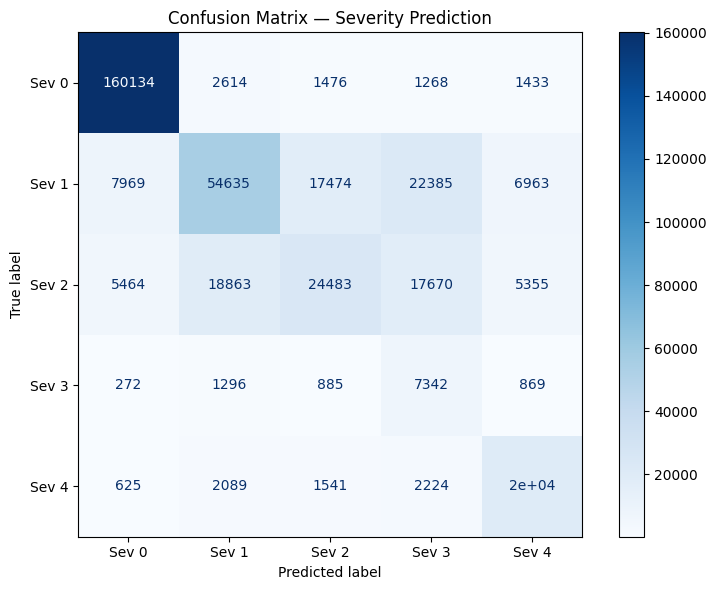

  Confusion matrix saved.


In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_orig, y_pred_orig),
    display_labels=[f'Sev {i}' for i in range(N_CLASSES)]
).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Severity Prediction')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset/confusion_matrix.png', dpi=150)
plt.show()
print("  Confusion matrix saved.")



Plotting feature importance...


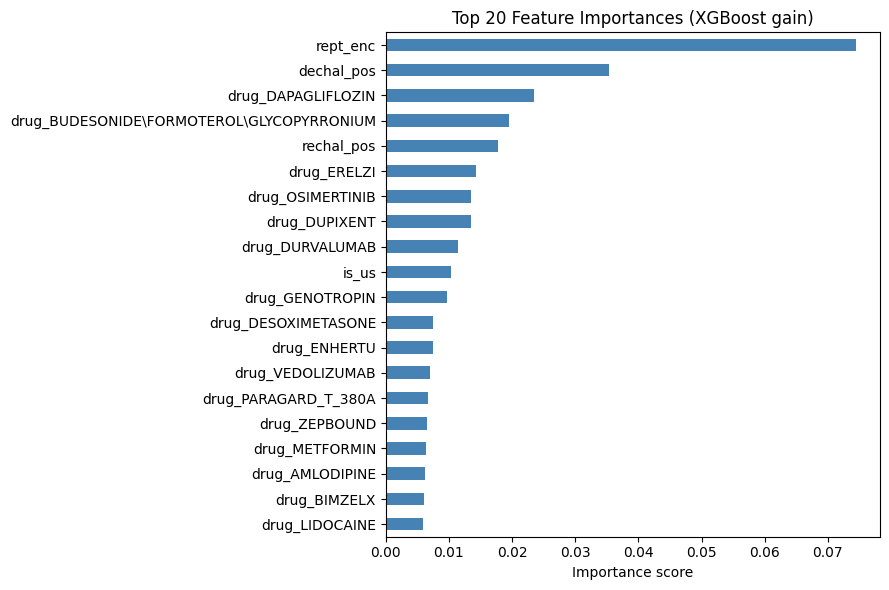

  Feature importance plot saved.


In [ ]:
print("\nPlotting feature importance...")

importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (XGBoost gain)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset/feature_importance.png', dpi=150)
plt.show()
print("  Feature importance plot saved.")

In [ ]:
model_path = '/content/drive/MyDrive/Dataset/faers_xgb_severity_v1.json'
model.save_model(model_path)
print(f"\n✅ Model saved → {model_path}")

# Save feature list for inference
feat_path = '/content/drive/MyDrive/Dataset/feature_cols_v1.pkl'
joblib.dump(FEATURE_COLS, feat_path)
print(f"✅ Feature list saved → {feat_path}")

print("\n🎉 Pipeline complete!")
print(f"   CV macro-F1 : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Features used: {len(FEATURE_COLS)}")
print(f"   Training rows: {len(X):,}")




✅ Model saved → /content/drive/MyDrive/Dataset/faers_xgb_severity_v1.json
✅ Feature list saved → /content/drive/MyDrive/Dataset/feature_cols_v1.pkl

🎉 Pipeline complete!
   CV macro-F1 : 0.5524 ± 0.0008
   Features used: 424
   Training rows: 385,133
